In [2]:
import pandas as pd

data = pd.read_csv("../data/clean_weather.csv", index_col=0)
VirtualData = pd.read_excel("../data/VirtualSamples.xlsx", sheet_name="Linear")
VirtualData = VirtualData.rename(columns={
    "x1": "tmax" ,
    "x2": "tmin",
    "f(x1,x2)": "tmax_tomorrow"
})

data = data.ffill()

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def PlotTimeSeries(df, img_name="data.svg", PlotOut=False):    
    df.index = pd.to_datetime(df.index)

    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Tmax e Tmin como linhas
    sns.lineplot(x=df.index.day, y=df["tmax"], ax=ax1, marker="o", label="Tmax", color="red", linewidth=2)
    sns.lineplot(x=df.index.day, y=df["tmin"], ax=ax1, marker="o", label="Tmin", color="blue", linewidth=2)
    if (PlotOut):
        sns.lineplot(x=df.index.day, y=df["tmax_tomorrow"], ax=ax1, marker="o", label="Tmax Tomorrow", color="orange", linestyle="dashed", linewidth=2)

    # Criando um segundo eixo para a precipitação (rain)
    ax2 = ax1.twinx()
    sns.barplot(x=df.index.day, y=df["rain"], ax=ax2, color="gray", alpha=0.3, label="Precipitação", width=0.6)

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Data", fontsize=12)
    ax1.set_ylabel("Temperatura (°C)", fontsize=12, color="black")
    ax2.set_ylabel("Precipitação ", fontsize=12, color="gray")

    # Rotacionando os rótulos das datas
    plt.xticks(rotation=45, fontsize=5)

    # Adicionando legendas
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    # Título
    plt.title("Variação de Temperatura e Precipitação", fontsize=14)
    plt.savefig(f"content/{img_name}", format="svg", dpi=600)
    # Exibindo o gráfico
    plt.show()

,tmax,tmin,rain,tmax_tomorrow


/tmp/ipykernel_150992/2509920584.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper left")
/tmp/ipykernel_150992/2509920584.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right")


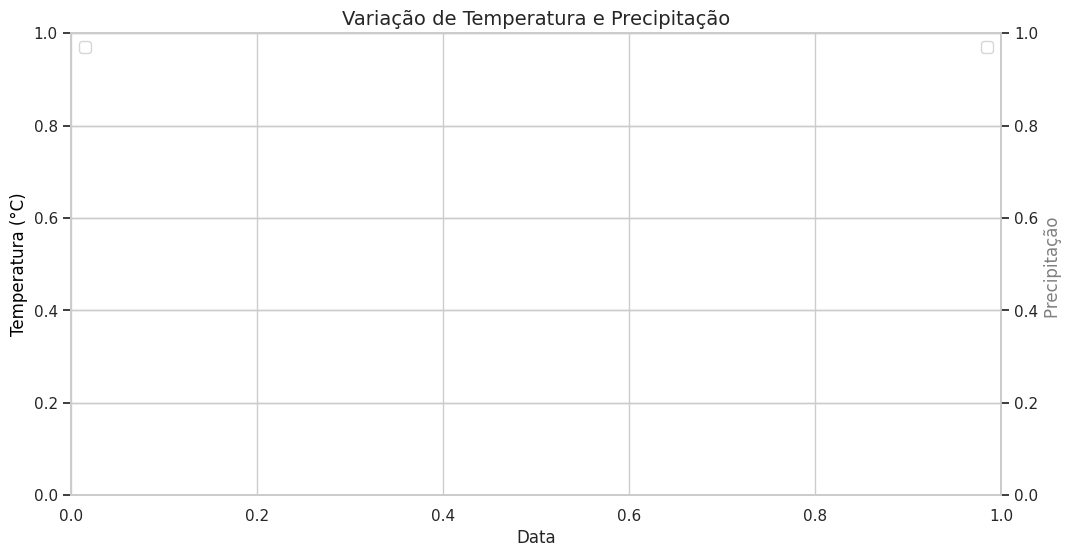

ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define predictors and target
PREDICTORS = ["tmax", "tmin", "rain"]
TARGET = "tmax_tomorrow"

# Scale our data to have mean 0
scaler = StandardScaler()

data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

# Random sampling doesn't make sense because we lose the time information
# data = data.sample(25, random_state=42)

df = data.tail(32).merge(VirtualData, on=["tmax", "tmin", "tmax_tomorrow"], how="inner")

display(df)
PlotTimeSeries(df)

# # Split into train (70%), validation (15%), and test (15%) sets
# train_data, temp_data = train_test_split(df, test_size=0.3, random_state=0)
# valid_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=0)

# # Convertendo para arrays numpy
# train_x = train_data[PREDICTORS].to_numpy()
# train_y = train_data[[TARGET]].to_numpy()

# x_val = valid_data[PREDICTORS].to_numpy()
# y_val = valid_data[[TARGET]].to_numpy()

# x_test = test_data[PREDICTORS].to_numpy()
# y_test = test_data[[TARGET]].to_numpy()


In [5]:
import matplotlib.pyplot as plt
import keras
from keras import layers, models, regularizers
from keras.callbacks import EarlyStopping

def compile_model(model, epochs=100):
    # Compilando o modelo
    model.compile(loss="mse", optimizer="adam")

    # Definindo o early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Treinando o modelo
    history = model.fit(
        train_x, train_y,
        epochs=epochs,
        validation_data=(x_val, y_val),
        callbacks=[early_stop],
        verbose=False
    )

    # Avaliando o modelo
    mse_v = model.evaluate(x_val, y_val)
    print(f"Validation MSE: {mse_v:.4f}")
    
    mse_t = model.evaluate(x_test, y_test)
    print(f"Test MSE: {mse_t:.4f}")

    # Plotando o histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()


Treinando modelo com hidden_size = 1


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3783.3511
Validation MSE: 3783.3511
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3628.5054
Test MSE: 3628.5054


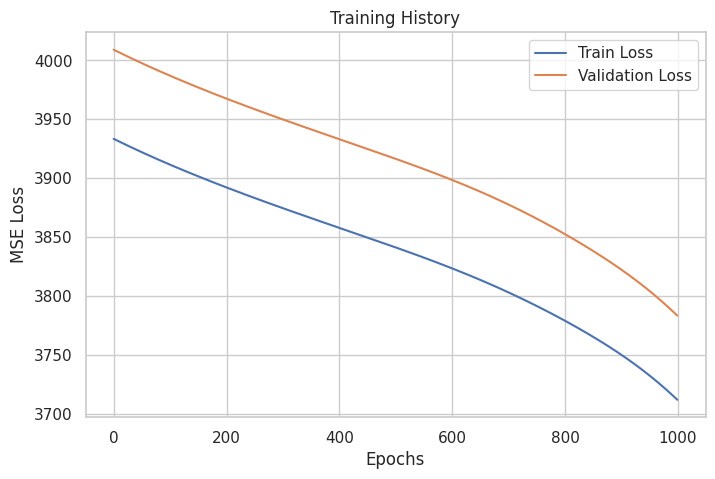


Treinando modelo com hidden_size = 5


In [ ]:
for hidden_size in [1, 5, 10, 15, 20, 25, 30]:
    print(f"\nTreinando modelo com hidden_size = {hidden_size}")
    
    model = models.Sequential([
        layers.SimpleRNN(
            hidden_size,
            return_sequences=True,
            input_shape=[3, 1],
            kernel_regularizer=regularizers.l2(0.01)  # Regularização L2
        ),
        layers.Dense(1, kernel_regularizer=regularizers.l2(0.01))
    ])
    
    compile_model(model, epochs=1000)
